# Projet Machine Learning - PredictObesity

Prédiction de l'obésité à partir de données de santé et de mode de vie.

## Chargement des données

Source : [Kaggle - Obesity Data Set](https://www.kaggle.com/datasets/adeniranstephen/obesity-prediction-dataset)

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
from pathlib import Path

DATA_DIR = Path.cwd() / "data"
CSV_FILE_PATH = DATA_DIR / "ObesityDataSet_raw_and_data_sinthetic.csv"

In [153]:
df = pd.read_csv(CSV_FILE_PATH)

df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Analyse exploratoire des données (EDA)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Colonnes :

- Gender – Male or Female.
- Age – The person’s age in years.
- Height – Height in meters.
- Weight – Weight in kilograms.
- family_history_with_overweight – Whether the person has a family history of being overweight (yes/no).
- FAVC – If the person frequently consumes high-calorie foods (yes/no).
- FCVC – Frequency of vegetable consumption (scale from 1 to 3).
- NCP – Number of main meals per day.
- CAEC – Frequency of consuming food between meals (Never, Sometimes, Frequently, Always).
- SMOKE – Whether the person smokes (yes/no).
- CH2O – Daily water intake (scale from 1 to 3).
- SCC – If the person monitors their calorie intake (yes/no).
- FAF – Physical activity frequency (scale from 0 to 3).
- TUE – Time spent using technology (scale from 0 to 3).
- CALC – Frequency of alcohol consumption (Never, Sometimes, Frequently, Always).
- MTRANS – Main mode of transportation (Automobile, Bike, Motorbike, Public Transportation, Walking).
- NObeyesdad – Obesity level (Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, Obesity Type III).

In [119]:
colonnes = list(df.columns)

colonnes

['Gender',
 'Age',
 'Height',
 'Weight',
 'family_history_with_overweight',
 'FAVC',
 'FCVC',
 'NCP',
 'CAEC',
 'SMOKE',
 'CH2O',
 'SCC',
 'FAF',
 'TUE',
 'CALC',
 'MTRANS',
 'NObeyesdad']

1. **Variable cible : `NObeyesdad`**

In [154]:
def pie_plot(s, title):
    svc = s.value_counts()
    # plt.figure(figsize=(8, 8))
    plt.pie(
        x=svc,
        labels=svc.index,
        colors=sns.color_palette("deep"),
        autopct="%0.2f%%",startangle=90
    )
    plt.title(title)
    plt.show()

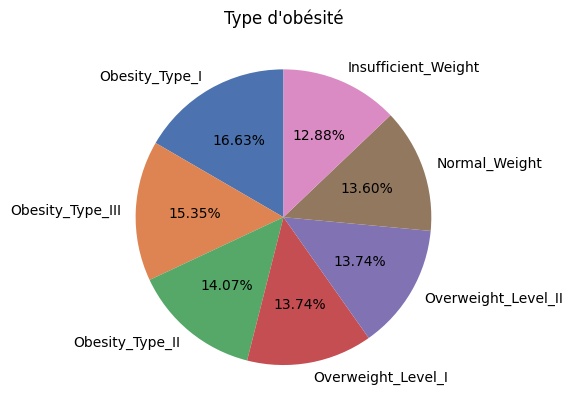

In [155]:
pie_plot(df["NObeyesdad"], "Type d'obésité")

In [122]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [123]:
len(df['NObeyesdad'].value_counts())

7

Il y a 7 types d'obésité différents dans ce dataset. Nous sommes sur un problème de classification multiclasse.

Les classes sont globalement bien équilibrées ce qui facilitera l'entraînement des modèles.

2. **Variable `Gender`**

In [124]:
df["Gender"].value_counts(normalize=True)

Gender
Male      0.505921
Female    0.494079
Name: proportion, dtype: float64

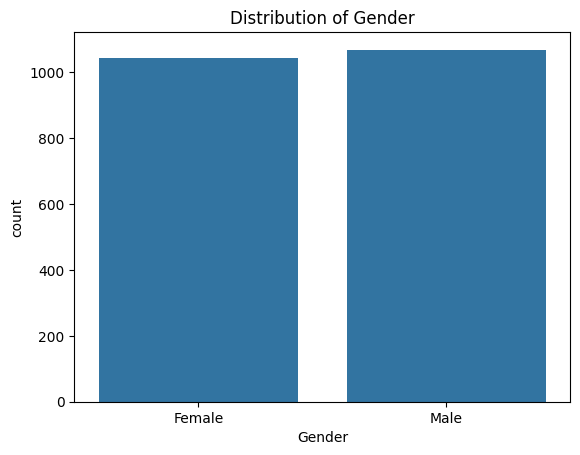

In [125]:
sns.countplot(data=df, x="Gender")
plt.title("Distribution of Gender")
plt.show()

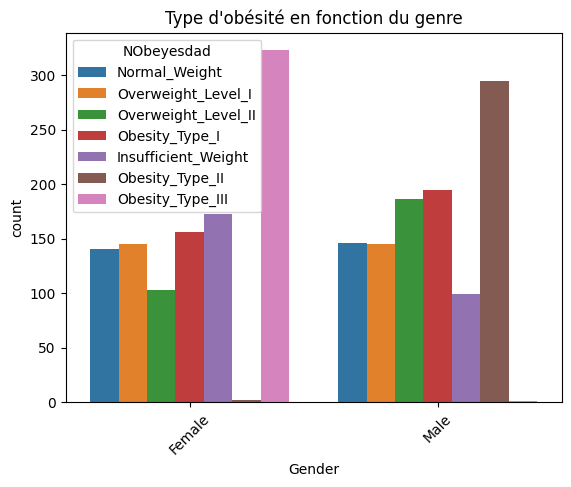

In [126]:
sns.countplot(data=df, x="Gender", hue="NObeyesdad")
plt.title("Type d'obésité en fonction du genre")
plt.xticks(rotation=45)
plt.show()

Les données de genre sont bien distribuées dans le dataset. Il semble que le genre influe fortement sur certains type d'obésité.

3. **Variable `age`**

In [127]:
df["Age"].describe()

count    2111.000000
mean       24.315964
std         6.357078
min        14.000000
25%        20.000000
50%        23.000000
75%        26.000000
max        61.000000
Name: Age, dtype: float64

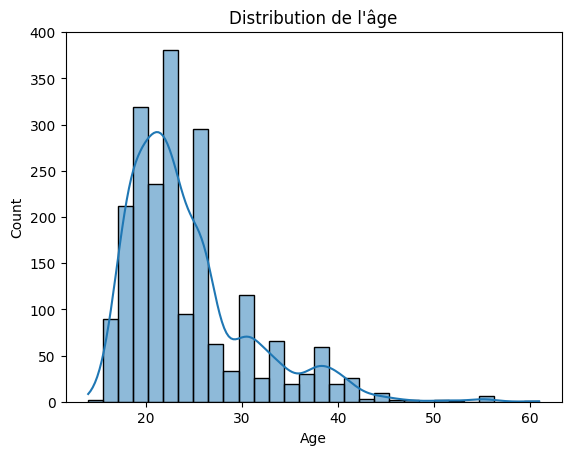

In [128]:
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.show()

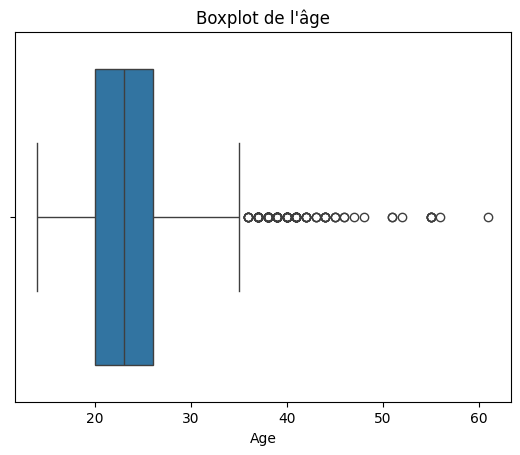

In [129]:
sns.boxplot(x=df["Age"])
plt.title("Boxplot de l'âge")
plt.show()

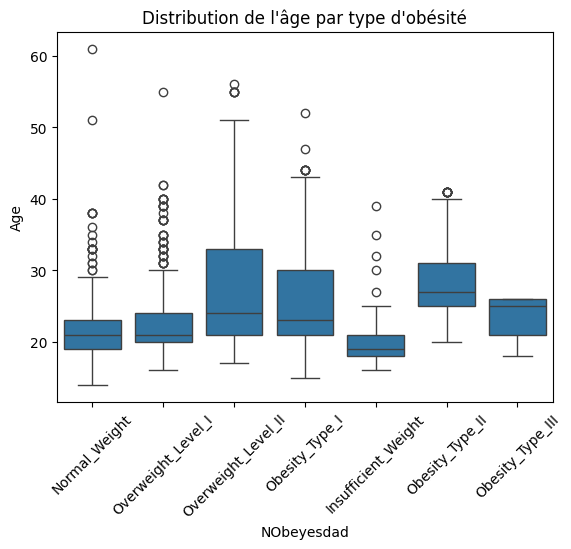

In [130]:
sns.boxplot(data=df, x="NObeyesdad", y="Age")
plt.xticks(rotation=45)
plt.title("Distribution de l'âge par type d'obésité")
plt.show()

La distribution de la variable age est normale. Il y a quelques outliers (age > 40 ans) car la majorité des données est centrée autour de 24 ans.

L'age semble influencer le type d'obésité. Par exemple un poids insuffisant est plutôt observé chez des individus jeunes. Cependant cette variable seule ne peut pas expliquer complètement la classe.

4. **Variable `Height`**

In [131]:
df["Height"].describe()

count    2111.000000
mean        1.701620
std         0.093368
min         1.450000
25%         1.630000
50%         1.700000
75%         1.770000
max         1.980000
Name: Height, dtype: float64

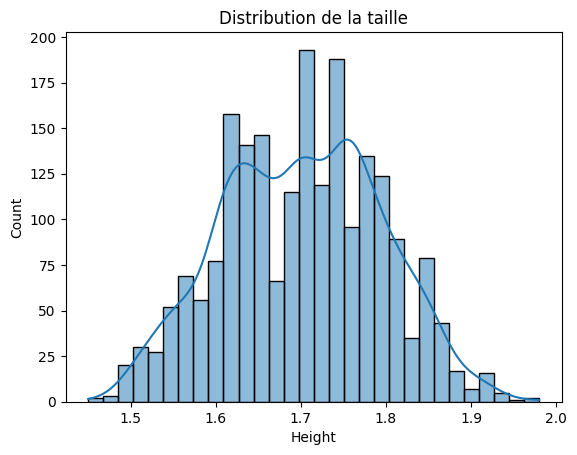

In [132]:
sns.histplot(data=df, x="Height", bins=30, kde=True)
plt.title("Distribution de la taille")
plt.show()

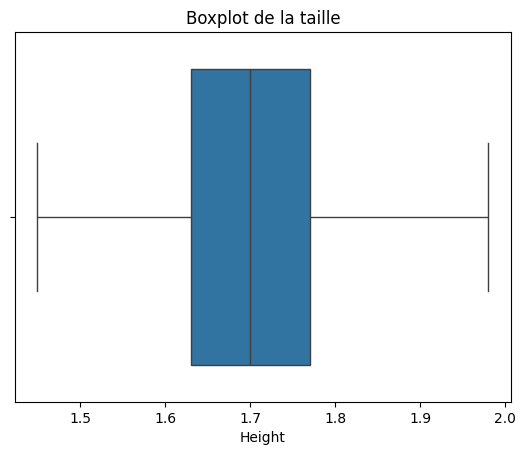

In [133]:
sns.boxplot(x=df["Height"])
plt.title("Boxplot de la taille")
plt.show()

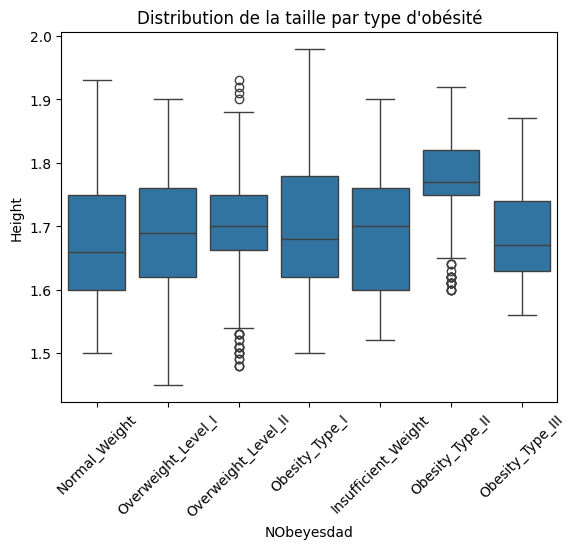

In [134]:
sns.boxplot(data=df, x="NObeyesdad", y="Height")
plt.xticks(rotation=45)
plt.title("Distribution de la taille par type d'obésité")
plt.show()

La distribution de la taille semble normale, sans valeurs aberrantes. Il semble y avoir une légère tendance à la taille plus élevée pour l'obésité de type II, hormis cela la répartition de la taille selon le type d'obésité parais normal.

5. **Variable `Weight`**

In [135]:
df["Weight"].describe()

count    2111.000000
mean       86.586035
std        26.191163
min        39.000000
25%        65.470000
50%        83.000000
75%       107.430000
max       173.000000
Name: Weight, dtype: float64

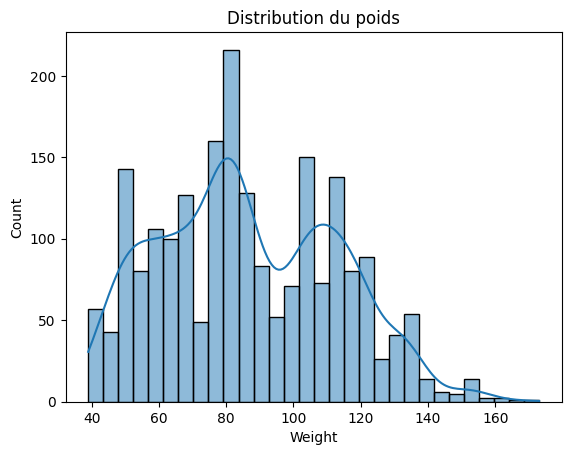

In [136]:
sns.histplot(data=df, x="Weight", bins=30, kde=True)
plt.title("Distribution du poids")
plt.show()

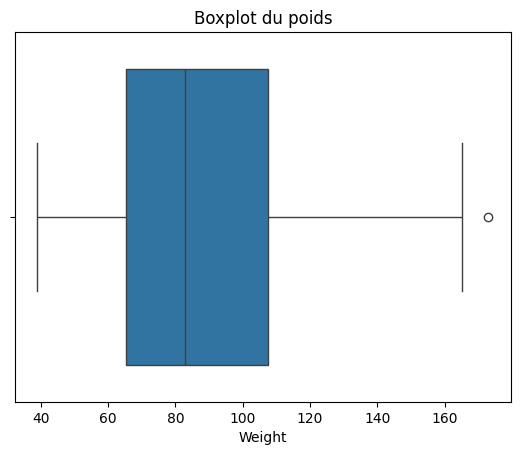

In [137]:
sns.boxplot(x=df["Weight"])
plt.title("Boxplot du poids")
plt.show()

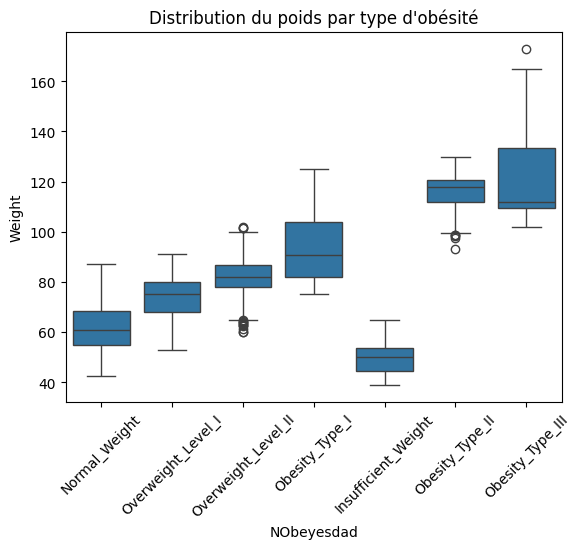

In [138]:
sns.boxplot(data=df, x="NObeyesdad", y="Weight")
plt.xticks(rotation=45)
plt.title("Distribution du poids par type d'obésité")
plt.show()

La distribution du poids semble être normale, avec quelques valeurs extrêmes. Le poids semble fortement influencer le type d'obésité.

6. **Variable `family_history_with_overweight`** (antécédents familiaux de surpoids)

In [139]:
df['family_history_with_overweight'].value_counts(normalize=True)

family_history_with_overweight
yes    0.817622
no     0.182378
Name: proportion, dtype: float64

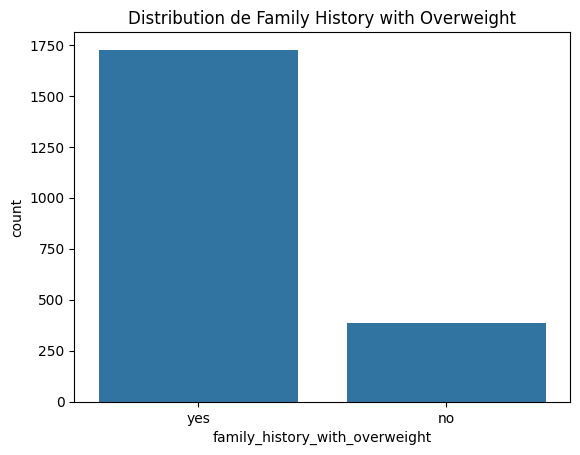

In [140]:
sns.countplot(data=df, x="family_history_with_overweight")
plt.title("Distribution de Family History with Overweight")
plt.show()

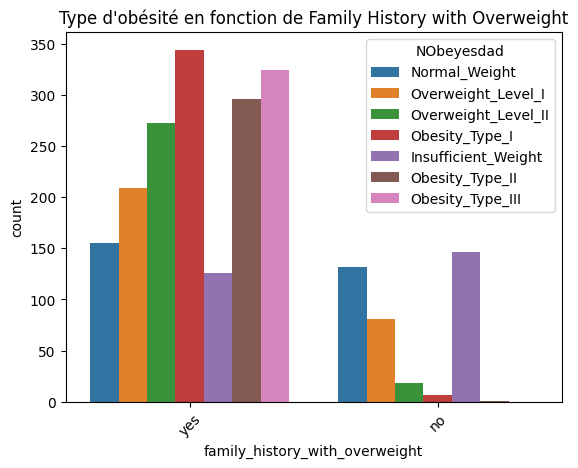

In [141]:
sns.countplot(data=df, x="family_history_with_overweight", hue="NObeyesdad")
plt.title("Type d'obésité en fonction de Family History with Overweight")
plt.xticks(rotation=45)
plt.show()

Nous avons dans notre dataset une majorité d'antécédents d'obésité dans la famille (81 %). Cela semble influencer tous les types d'obésité hormis le poids normal et le poids insuffisant.

7. **Variable `FAVC`** (Fréquence de consommation d'aliments riches en calories)

In [142]:
df['FAVC'].value_counts(normalize=True)

FAVC
yes    0.883941
no     0.116059
Name: proportion, dtype: float64

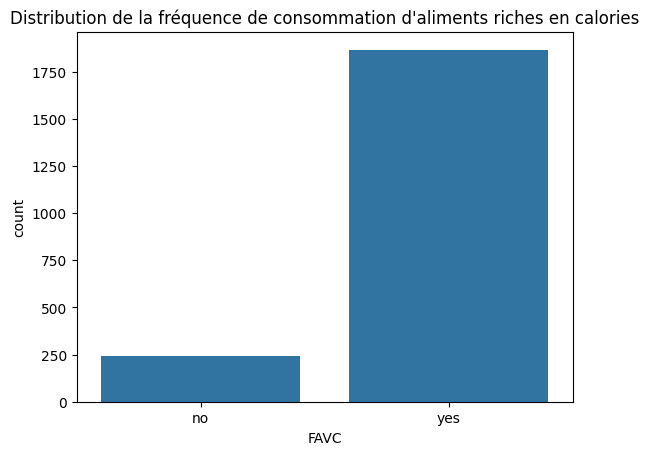

In [143]:
sns.countplot(data=df, x="FAVC")
plt.title("Distribution de la fréquence de consommation d'aliments riches en calories")
plt.show()

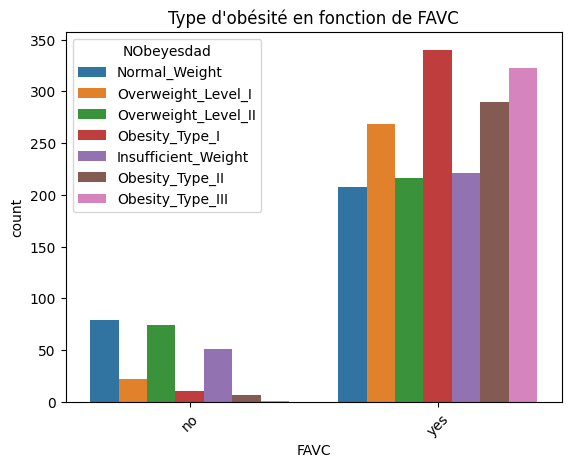

In [144]:
sns.countplot(data=df, x="FAVC", hue="NObeyesdad")
plt.title("Type d'obésité en fonction de FAVC")
plt.xticks(rotation=45)
plt.show()

88% du dataset consomme fréquemment des aliments riches en calories. La consommation fréquente d'aliments riches en calories semble être un facteur important dans la détermination du type d'obésité, avec une proportion plus élevée de personnes obèses parmi celles qui consomment fréquemment des aliments riches en calories.

8. **Variable `FCVC`** (Fréquence de consommation de fruits et légumes)

In [145]:
df["FCVC"].describe()

count    2111.000000
mean        2.418986
std         0.533996
min         1.000000
25%         2.000000
50%         2.390000
75%         3.000000
max         3.000000
Name: FCVC, dtype: float64

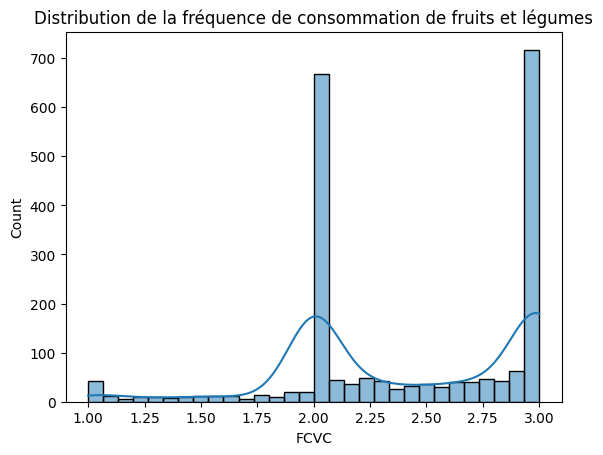

In [146]:
sns.histplot(data=df, x="FCVC", bins=30, kde=True)
plt.title("Distribution de la fréquence de consommation de fruits et légumes")
plt.show()

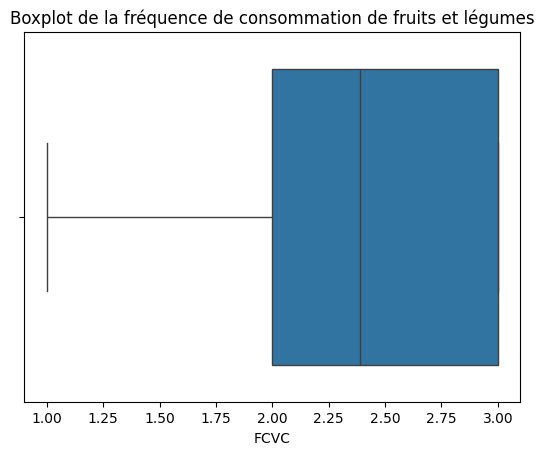

In [147]:
sns.boxplot(x=df["FCVC"])
plt.title("Boxplot de la fréquence de consommation de fruits et légumes")
plt.show()

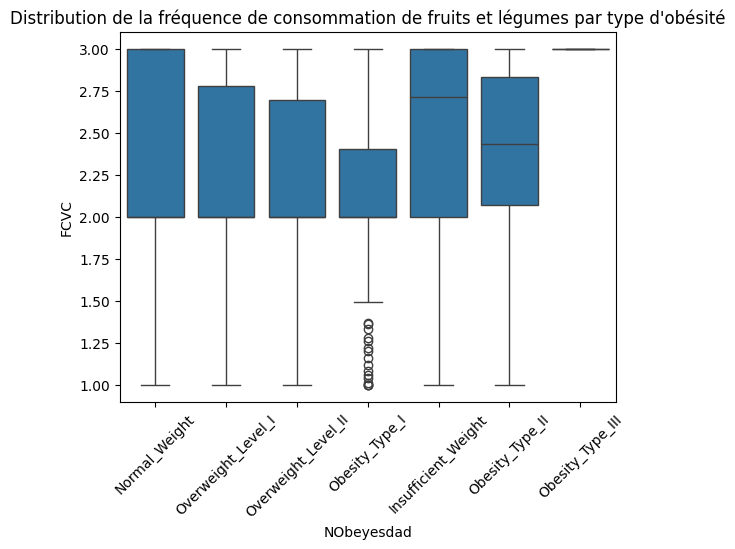

In [148]:
sns.boxplot(data=df, x="NObeyesdad", y="FCVC")
plt.xticks(rotation=45)
plt.title("Distribution de la fréquence de consommation de fruits et légumes par type d'obésité")
plt.show()

La distribution de FCVC n'est pas habituelle, il y a une forte concentration de personnes qui consomment des légumes 2 fois par jour et 3 fois par jour. La consommation de légumes semble être un facteur important dans la détermination du type d'obésité.

**Nous effectuerons une discrétisation (binning) de cette variable** pour faciliter la compréhension et l'entraînement des modèles.

9. **Variable `NCP`** (Nombre de repas principaux par jour)

In [149]:
df['NCP'].describe()

count    2111.000000
mean        2.685651
std         0.778079
min         1.000000
25%         2.660000
50%         3.000000
75%         3.000000
max         4.000000
Name: NCP, dtype: float64

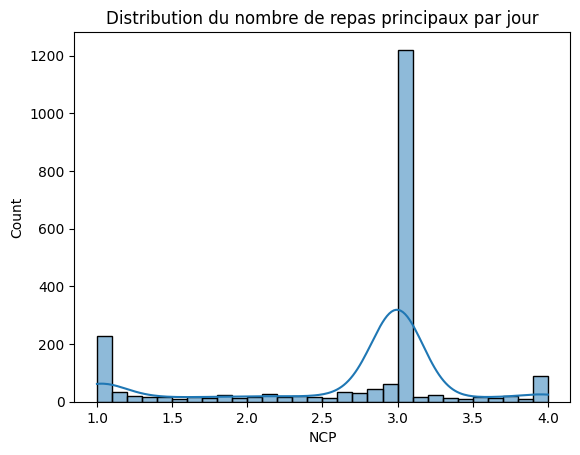

In [150]:
sns.histplot(data=df, x="NCP", bins=30, kde=True)
plt.title("Distribution du nombre de repas principaux par jour")
plt.show()

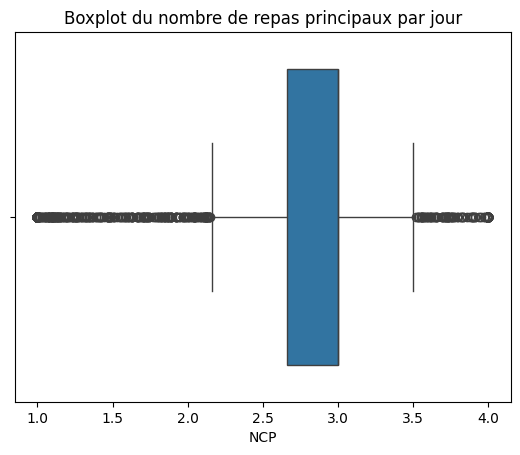

In [151]:
sns.boxplot(x=df["NCP"])
plt.title("Boxplot du nombre de repas principaux par jour")
plt.show()

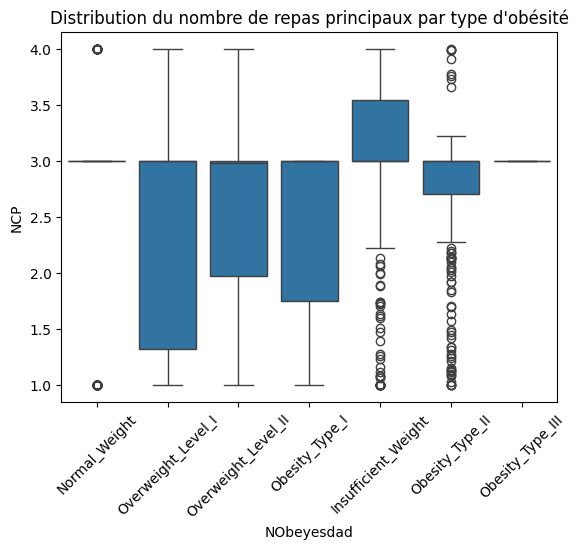

In [152]:
sns.boxplot(data=df, x="NObeyesdad", y="NCP")
plt.xticks(rotation=45)
plt.title("Distribution du nombre de repas principaux par type d'obésité")
plt.show()

La majorité des personnes dans le dataset consomme 3 repas principaux par jour. Nous avons des outliers (1 et 4 repas principaux par jour) mais cela révèle simplement qu'il faudra effectuer **une discrétisation de cette variable** pour faciliter la compréhension et l'entraînement des modèles.